## 1) Setup & Configuration

In [1]:
"""
This notebook configures and runs an LSTM-based individual identification experiment
using BirdNET embeddings extracted from segmented audio files. It supports multiple
datasets and evaluation settings through a modular configuration block.

Main functionalities
- Sets a global random seed for reproducibility using Lightning.
- Defines dataset, experiment, input, and output paths relative to the project root.
- Supports sequence-level experiments with either ordered or shuffled embedding sequences.
- Loads metadata and embedding parts required for training, validation, and testing.
- Configures logging, metrics, classification reports, and figure output directories.
- Specifies model hyperparameters for the BirdNET + LSTM pipeline.

Supported datasets
- chiffchaff: supports within-year and across-year splits.
- pipit: supports within-year and across-year splits.
- littleowl: supports across-year only.

Key configuration variables
- SEED: Random seed used for reproducibility in dataset splitting, shuffling, and training.
- DATASET_NAME: Dataset to use. Options: "chiffchaff", "pipit", "littleowl".
- SPLIT_TYPE: Evaluation subset to use. Options depend on the dataset.
- SEQUENCE: Sequence mode for the embeddings, either "ordered" or "shuffled".
- EXPERIMENT_TAG: Descriptive tag used to name the current experiment.
- PARENT_DIR: Project root directory used to build all relative paths.

Notes
- In shuffled mode, the temporal order of embeddings is destroyed while preserving the same
  embeddings and sequence lengths, enabling direct comparison against the ordered condition.
- Ensure that all input directories and metadata files exist before running the notebook.
"""

from lightning import seed_everything

SEED = 46
seed_everything(SEED, workers=True)

from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ---- Dataset config ----
DATASET_NAME = "littleowl"   # options: "chiffchaff", "pipit", "littleowl"
SPLIT_TYPE = "acrossyear"     # options depend on dataset
SEQUENCE = "shuffled"         # options: "ordered", "shuffled"

EXPERIMENT_TAG = f"birdnet_lstm_{SEQUENCE}"
PARENT_DIR = Path.cwd().parent

# Dataset-specific configuration
DATASET_CONFIG = {
    "chiffchaff": {
        "metadata_dir": "chiffchaff-fg",
        "label_key_col": "wavfilename",
        "allowed_splits": {"withinyear", "acrossyear"},
        "train_files": {
            "withinyear": "chiffchaff-withinyear-fg-trn.csv",
            "acrossyear": "chiffchaff-acrossyear-fg-trn.csv",
        },
        "test_files": {
            "withinyear": "chiffchaff-withinyear-fg-tst.csv",
            "acrossyear": "chiffchaff-acrossyear-fg-tst.csv",
        },
    },
    "pipit": {
        "metadata_dir": "pipit-fg",
        "label_key_col": "wavfilename",
        "allowed_splits": {"withinyear", "acrossyear"},
        "train_files": {
            "withinyear": "pipit-withinyear-fg-trn.csv",
            "acrossyear": "pipit-acrossyear-fg-trn.csv",
        },
        "test_files": {
            "withinyear": "pipit-withinyear-fg-tst.csv",
            "acrossyear": "pipit-acrossyear-fg-tst.csv",
        },
    },
    "littleowl": {
        "metadata_dir": "littleowl-fg",
        "label_key_col": "wavfilename",
        "allowed_splits": {"acrossyear"},
        "train_files": {
            "acrossyear": "littleowl-acrossyear-fg-trn.csv",
        },
        "test_files": {
            "acrossyear": "littleowl-acrossyear-fg-tst.csv",
        },
    },
}

if DATASET_NAME not in DATASET_CONFIG:
    raise ValueError(
        f"Unknown DATASET_NAME: {DATASET_NAME}. "
        f"Choose from {list(DATASET_CONFIG.keys())}."
    )

cfg = DATASET_CONFIG[DATASET_NAME]

if SPLIT_TYPE not in cfg["allowed_splits"]:
    raise ValueError(
        f"Dataset '{DATASET_NAME}' does not support split '{SPLIT_TYPE}'. "
        f"Allowed splits: {sorted(cfg['allowed_splits'])}"
    )

# ---- Input paths ----
PARTS_DIR = (
    PARENT_DIR
    / "Output_files"
    / "Embeddings_from_3sPadding"
    / f"{DATASET_NAME}_parquet_parts"
)

METADATA_DIR = PARENT_DIR / "Output_metadata" / cfg["metadata_dir"]
TRN_CSV = METADATA_DIR / cfg["train_files"][SPLIT_TYPE]
TST_CSV = METADATA_DIR / cfg["test_files"][SPLIT_TYPE]

# ---- Data columns ----
LABEL_KEY_COL = cfg["label_key_col"]
EMB_KEY_COL = "file_name"

# Optional quick subset of parts (0 = use all)
LIMIT_N_PARTS = 0

# ---- Output paths ----
LOG_ROOT = PARENT_DIR / "logs"
RUN_NAME = f"{DATASET_NAME}_{SPLIT_TYPE}_{EXPERIMENT_TAG}"
LOG_DIR = LOG_ROOT / DATASET_NAME / SPLIT_TYPE
LOG_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_DIR = PARENT_DIR / "Results" / DATASET_NAME / SPLIT_TYPE
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

METRICS_DIR = RESULTS_DIR / "Metrics"
METRICS_DIR.mkdir(parents=True, exist_ok=True)

METRICS_FILE = METRICS_DIR / f"{RUN_NAME}_final_metrics.csv"
CLASS_REPORT_TXT_FILE = METRICS_DIR / f"{RUN_NAME}_test_classification_report.txt"
CLASS_REPORT_CSV_FILE = METRICS_DIR / f"{RUN_NAME}_test_classification_report.csv"

FIGURES_DIR = RESULTS_DIR / f"{RUN_NAME}_figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("TensorBoard logs will go to:", LOG_DIR / RUN_NAME)

# ---- Model hyperparameters ----
EMBEDDING_DIM = 1024
HIDDEN_DIM = 256
LEARNING_RATE = 1e-3

print("DATASET_NAME:", DATASET_NAME)
print("SPLIT_TYPE:", SPLIT_TYPE)
print("SEQUENCE:", SEQUENCE)
print("PARTS_DIR:", PARTS_DIR)
print("TRN_CSV:", TRN_CSV)
print("TST_CSV:", TST_CSV)
print("LOG_DIR:", LOG_DIR / RUN_NAME)
print("METRICS_FILE:", METRICS_FILE)
print("FIGURES_DIR:", FIGURES_DIR)

Seed set to 46


TensorBoard logs will go to: /teamspace/studios/this_studio/logs/littleowl/acrossyear/littleowl_acrossyear_birdnet_lstm_shuffled
DATASET_NAME: littleowl
SPLIT_TYPE: acrossyear
SEQUENCE: shuffled
PARTS_DIR: /teamspace/studios/this_studio/Output_files/Embeddings_from_3sPadding/littleowl_parquet_parts
TRN_CSV: /teamspace/studios/this_studio/Output_metadata/littleowl-fg/littleowl-acrossyear-fg-trn.csv
TST_CSV: /teamspace/studios/this_studio/Output_metadata/littleowl-fg/littleowl-acrossyear-fg-tst.csv
LOG_DIR: /teamspace/studios/this_studio/logs/littleowl/acrossyear/littleowl_acrossyear_birdnet_lstm_shuffled
METRICS_FILE: /teamspace/studios/this_studio/Results/littleowl/acrossyear/Metrics/littleowl_acrossyear_birdnet_lstm_shuffled_final_metrics.csv
FIGURES_DIR: /teamspace/studios/this_studio/Results/littleowl/acrossyear/littleowl_acrossyear_birdnet_lstm_shuffled_figures


## 2) Load and combine labels (one-hot → single label per file)

In [2]:
from pathlib import Path
import pandas as pd

# ---- Load available CSVs (train required, test optional) ----
csv_paths = []
if 'TRN_CSV' in locals() and TRN_CSV is not None and Path(TRN_CSV).exists():
    csv_paths.append(TRN_CSV)
if 'TST_CSV' in locals() and TST_CSV is not None and Path(TST_CSV).exists():
    csv_paths.append(TST_CSV)

if not csv_paths:
    raise ValueError("No label CSVs found. Provide at least TRN_CSV.")

dfs = [pd.read_csv(p) for p in csv_paths]
combined_df = pd.concat(dfs, ignore_index=True)

# ---- Choose schema: single-label vs one-hot ----

# Case A: single label column present (e.g., 'class')
SINGLE_LABEL_COLS = [c for c in ["class", "label", "individual_id"] if c in combined_df.columns]

if SINGLE_LABEL_COLS:
    LABEL_VALUE_COL = SINGLE_LABEL_COLS[0]  # pick the first available
    # Build label column directly
    combined_df["label"] = combined_df[LABEL_VALUE_COL].astype(str)

    # Normalize filenames for robust matching with embeddings
    if LABEL_KEY_COL not in combined_df.columns:
        raise ValueError(f"Missing filename column '{LABEL_KEY_COL}' in label CSV(s).")
    combined_df[LABEL_KEY_COL] = combined_df[LABEL_KEY_COL].astype(str).str.lower()

    combined_labels_dict = dict(zip(combined_df[LABEL_KEY_COL], combined_df["label"]))
    label_keys = set(combined_labels_dict.keys())

    print(f"[Single-label schema] Using '{LABEL_VALUE_COL}' as labels.")
    print(f"Loaded {len(combined_df):,} label rows; unique labeled audio files: {len(label_keys):,}")
    print("Example mapping:", list(combined_labels_dict.items())[:3])

else:
    # Case B: one-hot schema 
    if LABEL_KEY_COL not in combined_df.columns:
        raise ValueError(f"Missing filename column '{LABEL_KEY_COL}' in label CSV(s).")

    indiv_cols = [c for c in combined_df.columns if c != LABEL_KEY_COL]
    if not indiv_cols:
        raise ValueError("No one-hot individual columns found in the labels CSVs.")

    row_sums = combined_df[indiv_cols].sum(axis=1)
    if (row_sums == 0).all():
        raise ValueError("All rows in the one-hot block are zeros; no labeled files detected.")

    # One-hot → single string label: the column name containing the 1
    combined_df["label"] = combined_df[indiv_cols].idxmax(axis=1)

    # Normalize filenames
    combined_df[LABEL_KEY_COL] = combined_df[LABEL_KEY_COL].astype(str).str.lower()

    combined_labels_dict = dict(zip(combined_df[LABEL_KEY_COL], combined_df["label"]))
    label_keys = set(combined_labels_dict.keys())

    print(f"[One-hot schema] Derived labels from one-hot columns (n={len(indiv_cols)}).")
    print(f"Loaded {len(combined_df):,} label rows; unique labeled audio files: {len(label_keys):,}")
    print("Example mapping:", list(combined_labels_dict.items())[:3])


[One-hot schema] Derived labels from one-hot columns (n=16).
Loaded 952 label rows; unique labeled audio files: 952
Example mapping: [('littleowl2017fg_train_108_0000.wav', '108'), ('littleowl2017fg_train_108_0001.wav', '108'), ('littleowl2017fg_train_108_0002.wav', '108')]


## 3) Read embeddings from Parquet parts and keep only labeled files

This loads one part at a time to keep memory usage reasonable.

In [3]:
# Find Parquet parts
parts = sorted(PARTS_DIR.glob("part_*.parquet"))
if LIMIT_N_PARTS > 0:
    parts = parts[:LIMIT_N_PARTS]

if not parts:
    raise FileNotFoundError(f"No parquet parts found in: {PARTS_DIR}")

print(f"Found {len(parts)} parquet parts; first 3:", [p.name for p in parts[:3]])

# Build a single DataFrame of labeled embeddings 
# Note: we drop a 'path' column only if it exists in the Parquet schema.
kept_chunks = []
for part in parts:
    df_part = pd.read_parquet(part)

    # Normalize filename column for matching
    if EMB_KEY_COL not in df_part.columns:
        raise ValueError(f"Parquet part {part.name} missing column '{EMB_KEY_COL}'")

    df_part[EMB_KEY_COL] = df_part[EMB_KEY_COL].astype(str).str.lower()

    # Filter to labeled files only
    df_part = df_part[df_part[EMB_KEY_COL].isin(label_keys)]
    if df_part.empty:
        continue

    # Drop 'path' if present (your Parquet may not have it)
    if "path" in df_part.columns:
        df_part = df_part.drop(columns=["path"])

    kept_chunks.append(df_part)

# Concatenate all kept rows
if kept_chunks:
    trainvaltest_df = pd.concat(kept_chunks, ignore_index=True)
else:
    trainvaltest_df = pd.DataFrame()
    print("Warning: No embeddings matched the labeled filenames.")

print(f"Total kept rows after filtering by labels: {len(trainvaltest_df):,}")


Found 1 parquet parts; first 3: ['part_0000.parquet']
Total kept rows after filtering by labels: 952


## 4) Attach the label to each embedding row

In [4]:
# Map file_name → label
trainvaltest_df["label"] = trainvaltest_df[EMB_KEY_COL].map(combined_labels_dict)

# (Optional) sanity: any missing labels after mapping?
missing = trainvaltest_df["label"].isna().sum()
if missing:
    print(f"Warning: {missing} rows had missing labels after mapping.")


## 5) Stratified split by file (train/val/test)

First split 80/20, then split the 80 into 60/20.

In [5]:
# Unique file-level table (one row per file with its label)
file_labels = trainvaltest_df[[EMB_KEY_COL, "label"]].drop_duplicates()

# 1) 80/20 split (train+val / test)
train_val_files_only, test_files_only = train_test_split(
    file_labels,
    test_size=0.20,
    stratify=file_labels["label"],
    random_state=SEED+19,
)

# 2) Split the 80 into 60/20 (train / val)
train_files_only, val_files_only = train_test_split(
    train_val_files_only,
    test_size=0.25,  # 25% of 80% → 20% total
    stratify=train_val_files_only["label"],
    random_state=SEED+19,
)

# 3) Build final row-level DataFrames by selecting rows for those file sets
train_df = trainvaltest_df[trainvaltest_df[EMB_KEY_COL].isin(train_files_only[EMB_KEY_COL])].copy()
val_df   = trainvaltest_df[trainvaltest_df[EMB_KEY_COL].isin(val_files_only[EMB_KEY_COL])].copy()
test_df  = trainvaltest_df[trainvaltest_df[EMB_KEY_COL].isin(test_files_only[EMB_KEY_COL])].copy()

train_df = train_df.sort_index()
val_df   = val_df.sort_index()
test_df  = test_df.sort_index()

print(f"Train: {len(train_df):,} rows")
print(f"Validation: {len(val_df):,} rows")
print(f"Test: {len(test_df):,} rows")

print("Labels in TRN:", sorted(train_df["label"].unique()))
print("Labels in VAL:", sorted(val_df["label"].unique()))
print("Labels in TST:", sorted(test_df["label"].unique()))


Train: 570 rows
Validation: 191 rows
Test: 191 rows
Labels in TRN: ['108', '193', '229', '7', '94', 'BRE', 'CER', 'DUB', 'KME', 'LIS', 'MNE', 'PAL', 'RAC', 'RADBF', 'RADK', 'VEV']
Labels in VAL: ['108', '193', '229', '7', '94', 'BRE', 'CER', 'DUB', 'KME', 'LIS', 'MNE', 'PAL', 'RAC', 'RADBF', 'RADK', 'VEV']
Labels in TST: ['108', '193', '229', '7', '94', 'BRE', 'CER', 'DUB', 'KME', 'LIS', 'MNE', 'PAL', 'RAC', 'RADBF', 'RADK', 'VEV']


## 6) Label encode

In [6]:
le = LabelEncoder()

# Fit on training labels only
train_df["label"] = le.fit_transform(train_df["label"])

# Transform val/test consistently
val_df["label"] = le.transform(val_df["label"])
test_df["label"] = le.transform(test_df["label"])

print("Encoded classes:", list(le.classes_))


Encoded classes: ['108', '193', '229', '7', '94', 'BRE', 'CER', 'DUB', 'KME', 'LIS', 'MNE', 'PAL', 'RAC', 'RADBF', 'RADK', 'VEV']


## 7) Prepare Datasets for PyTorch

In [7]:
from torch.utils.data import Dataset
import torch

# Build both dicts in one pass per split
def build_per_file_dicts(df, key_col, dims_cols, label_col):
    """Return (embeddings_dict, id_dict, file_list) from a split DataFrame."""
    embeddings_dict = {}
    id_dict = {}
    for file_name, group in df.groupby(key_col, sort=False):
        # Sort by time to keep frames ordered
        group = group.sort_values(by="start_time")
        # Embeddings matrix (n_frames, n_dims)
        embeddings_dict[file_name] = group[dims_cols].to_numpy()
        # Per-file label (assumed constant for all frames of the file)
        id_dict[file_name] = group[label_col].iloc[0]
    files = list(id_dict.keys())
    return embeddings_dict, id_dict, files

# Identify embedding dimension columns
dims_cols = [c for c in train_df.columns if c.startswith("dim_")]

# Train
audio_train_embeddings, id_train_dict, train_files = build_per_file_dicts(
    train_df, EMB_KEY_COL, dims_cols, "label"
)

# Val
audio_val_embeddings, id_val_dict, val_files = build_per_file_dicts(
    val_df, EMB_KEY_COL, dims_cols, "label"
)

# Test
audio_test_embeddings, id_test_dict, test_files = build_per_file_dicts(
    test_df, EMB_KEY_COL, dims_cols, "label"
)

class SubsetAudioDataset(Dataset):
    """ Returns (embeddings, label) for a subset of files.
    Parameters
    ----------
    file_list : list
        List of file names belonging to the split.
    audio_embeddings : dict
        Dictionary mapping file_name -> embedding matrix of shape (n_frames, n_dims).
    file_to_label : dict
        Dictionary mapping file_name -> encoded class label.
    sequence_mode : str, default="ordered"
        Either "ordered" or "shuffled".
        - "ordered": returns embeddings in chronological order.
        - "shuffled": returns embeddings with a fixed temporal permutation per file.
    seed : int or None, default=None
        Seed used to generate reproducible permutations in shuffled mode.
    """
    def __init__(
        self, file_list, audio_embeddings, file_to_label, sequence_mode="ordered", seed=None,
    ):
        self.file_list = file_list
        self.audio_embeddings = audio_embeddings
        self.file_to_label = file_to_label
        self.sequence_mode = sequence_mode.lower()
        self.seed = seed

        if self.sequence_mode not in {"ordered", "shuffled"}:
            raise ValueError(f"Unknown sequence_mode: {sequence_mode}. Use 'ordered' or 'shuffled'.")

        # Precompute one fixed permutation per file for reproducibility.
        self.permutations = {}
        if self.sequence_mode == "shuffled":
            rng = np.random.default_rng(self.seed)
            for file_name in self.file_list:
                n_frames = self.audio_embeddings[file_name].shape[0]
                if n_frames > 1:
                    self.permutations[file_name] = rng.permutation(n_frames)
                else:
                    self.permutations[file_name] = None

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        file_name = self.file_list[idx]
        embeddings = self.audio_embeddings[file_name]
        if self.sequence_mode == "shuffled":
            perm = self.permutations[file_name]
            if perm is not None:
                embeddings = embeddings[perm]

        embeddings = torch.tensor(embeddings, dtype=torch.float32)
        label = torch.tensor(self.file_to_label[file_name], dtype=torch.long)

        return embeddings, label


# Create datasets
train_dataset = SubsetAudioDataset(train_files, audio_train_embeddings, id_train_dict, sequence_mode=SEQUENCE, seed=SEED)
val_dataset   = SubsetAudioDataset(val_files,   audio_val_embeddings,   id_val_dict,   sequence_mode=SEQUENCE, seed=SEED)
test_dataset  = SubsetAudioDataset(test_files,  audio_test_embeddings,  id_test_dict,  sequence_mode=SEQUENCE, seed=SEED)

print(f"Train size: {len(train_dataset)}")
print(f"Validation size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")


Train size: 570
Validation size: 191
Test size: 191


## 8) Counting Individual Frequencies per Dataset Split

,train,val,test
0,43,14,14
12,43,14,14
9,41,14,14
3,40,14,13
10,40,14,14
13,40,13,13
2,37,13,13
15,35,12,12
7,34,12,11
8,32,10,11


=== Dataset metrics (all splits combined) ===
Total vocalizations: 952
Maximum vocalizations per individual: 71
Minimum vocalizations per individual: 47
Vocalizations per individual (mean ± SD): 59.5 ± 8.2
Vocalizations per individual (mean ± SD, rounded): 60 ± 8


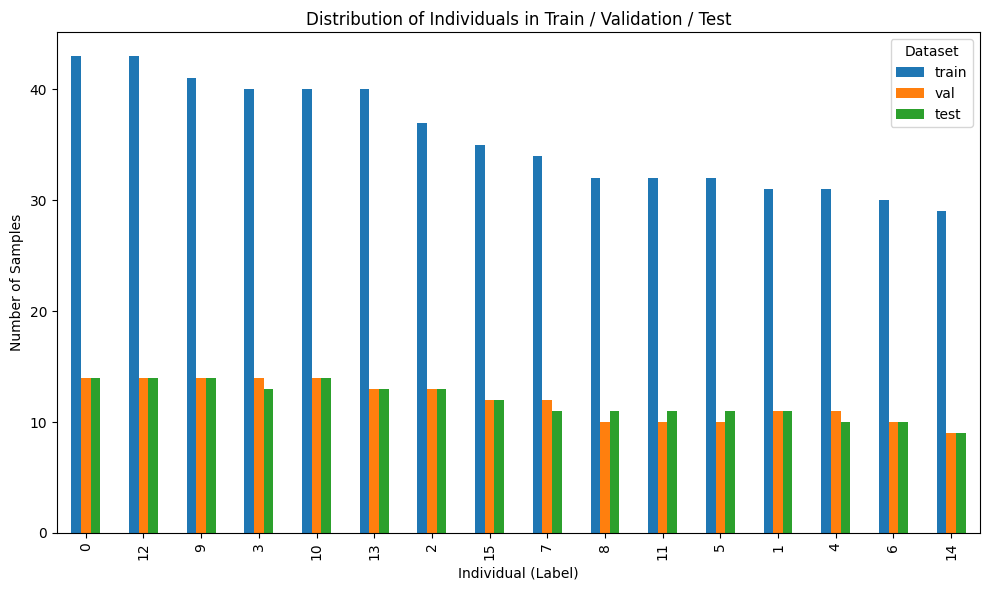

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

# --- Count labels in each split ---
def count_labels(dataset):
    """Count label frequencies in a PyTorch dataset."""
    return Counter(label.item() for _, label in dataset)

datasets = {
    "train": train_dataset,
    "val": val_dataset,
    "test": test_dataset
}

# Create DataFrame with counts
counts_df = pd.DataFrame({
    split: pd.Series(count_labels(ds))
    for split, ds in datasets.items()
}).fillna(0).astype(int)

# --- Sort by frequency in train ---
counts_df = counts_df.sort_values(by="train", ascending=False)

# --- Compute totals (not for plotting) ---
total_per_individual = counts_df.sum(axis=1)

# --- Metrics ---
total_vocalizations = int(total_per_individual.sum())
max_vocalizations   = int(total_per_individual.max())
min_vocalizations   = int(total_per_individual.min())
mean_vocalizations  = float(total_per_individual.mean())
std_vocalizations   = float(total_per_individual.std(ddof=1))  # sample SD

# --- Display counts DataFrame ---
display(counts_df)

# --- Print requested metrics ---
print("=== Dataset metrics (all splits combined) ===")
print(f"Total vocalizations: {total_vocalizations}")
print(f"Maximum vocalizations per individual: {max_vocalizations}")
print(f"Minimum vocalizations per individual: {min_vocalizations}")
print(f"Vocalizations per individual (mean ± SD): {mean_vocalizations:.1f} ± {std_vocalizations:.1f}")
print(f"Vocalizations per individual (mean ± SD, rounded): {round(mean_vocalizations):.0f} ± {round(std_vocalizations):.0f}")

# --- Plot per-split distribution ---
counts_df.plot(kind='bar', figsize=(10, 6))
plt.xlabel('Individual (Label)')
plt.ylabel('Number of Samples')
plt.title('Distribution of Individuals in Train / Validation / Test')
plt.legend(title='Dataset')
plt.tight_layout()
plt.show()


## 9) Lightning DataModule with Custom Collate (variable-length sequences)

In [9]:
from lightning import LightningDataModule
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import os

# --- Collate: pad variable-length sequences and return lengths ---
def custom_collate_fn(batch):
    sequences, labels = zip(*batch)  # sequences: [Tensor(n_i, d)], labels: [Tensor(,)]
    # Make sure types are consistent
    sequences = [seq.to(dtype=torch.float32) for seq in sequences]
    labels = torch.stack([lab.to(dtype=torch.long) for lab in labels])

    lengths = torch.tensor([len(seq) for seq in sequences], dtype=torch.long)
    # Pad to (B, T_max, D); default padding_value=0.0 is explicit here
    padded_sequences = nn.utils.rnn.pad_sequence(
        sequences, batch_first=True, padding_value=0.0
    )
    return padded_sequences, lengths, labels


class BirdsongDataModule(LightningDataModule):
    def __init__(
        self,
        train_dataset,
        val_dataset,
        test_dataset,
        batch_size: int = 32,
        num_workers: int = 0,              # 0 is safest in notebooks
        pin_memory: bool = False,          # set True if training on GPU
        persistent_workers: bool = False,  # True only if num_workers > 0
        drop_last: bool = False,           # set True if you need fixed batch shapes
    ):
        super().__init__()
        self.train_dataset = train_dataset
        self.val_dataset = val_dataset
        self.test_dataset = test_dataset

        self.batch_size = batch_size
        self.num_workers = num_workers
        self.pin_memory = pin_memory
        self.persistent_workers = persistent_workers if num_workers > 0 else False
        self.drop_last = drop_last

    def _make_loader(self, dataset, shuffle: bool):
        return DataLoader(
            dataset,
            batch_size=self.batch_size,
            shuffle=shuffle,
            collate_fn=custom_collate_fn,
            num_workers=self.num_workers,
            pin_memory=self.pin_memory,
            persistent_workers=self.persistent_workers,
            drop_last=self.drop_last,
        )

    def train_dataloader(self):
        return self._make_loader(self.train_dataset, shuffle=True)

    def val_dataloader(self):
        return self._make_loader(self.val_dataset, shuffle=False)

    def test_dataloader(self):
        return self._make_loader(self.test_dataset, shuffle=False)


# Example instantiation (tweak workers/pin_memory depending on your setup)
use_cuda = torch.cuda.is_available()
data_module = BirdsongDataModule(
    train_dataset,
    val_dataset,
    test_dataset,
    batch_size=32,
    num_workers=3,               # try >0 outside notebooks if IO becomes a bottleneck
    pin_memory=use_cuda,         # helpful when using CUDA
    persistent_workers=True,    # set True only if num_workers > 0
    drop_last=False,
)


## 10) LSTM-based Birdsong Classifier LightningModule

In [10]:
import torch
from torch import nn
import torch.nn.functional as F
from lightning import LightningModule
import torchmetrics
from torchmetrics.classification import F1Score
import logging
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)


class BirdsongClassifier(LightningModule):
    def __init__(
        self,
        embedding_dim: int,
        hidden_dim: int,
        num_classes: int,
        lr: float = 1e-3,
        bidirectional: bool = False,
        dropout: float = 0.0,
        use_mean_pool: bool = False,
        class_weights: torch.Tensor | None = None,  # pass on correct device later in setup()
    ):
        super().__init__()
        self.save_hyperparameters(ignore=["class_weights"])
        self.class_weights = class_weights  # store raw; move to device in setup()

        # LSTM
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if 1 < 1 else 0.0,  # dropout between layers if num_layers>1 (kept 1 layer here)
        )
        out_dim = hidden_dim * (2 if bidirectional else 1)

        self.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(out_dim, num_classes),
        )

        # Metrics (Lightning will aggregate over epoch)
        self.train_accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.val_accuracy   = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.test_accuracy  = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.val_f1         = torchmetrics.F1Score(task="multiclass", num_classes=num_classes, average="macro")
        self.test_f1        = torchmetrics.F1Score(task="multiclass", num_classes=num_classes, average="macro")

        # Loss (class weights optional; moved to device in setup())
        self.criterion = nn.CrossEntropyLoss(weight=None)

        self.use_mean_pool = use_mean_pool

    def setup(self, stage=None):
        # Move class weights to the right device if provided
        if self.class_weights is not None:
            self.criterion = nn.CrossEntropyLoss(weight=self.class_weights.to(self.device))

    def forward(self, x: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        # x: (B, T, D), lengths: (B,)
        packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, (h_n, c_n) = self.lstm(packed)

        if self.use_mean_pool:
            # Mean over valid timesteps (mask-aware)
            out, lens = pad_packed_sequence(packed_out, batch_first=True)  # (B, T_max, H[*2])
            lens = lens.to(out.device).clamp_min(1).unsqueeze(1)           # (B, 1)
            feats = out.sum(dim=1) / lens                                  # (B, H[*2])
        else:
            # Last hidden state from the top layer
            # h_n shape: (num_layers * num_directions, B, H)
            feats = h_n[-1]                                                # (B, H[*2] if bidirectional)

        logits = self.fc(feats)  # (B, C)
        return logits

    def training_step(self, batch, batch_idx):
        x, lengths, y = batch
        logits = self(x, lengths)
        loss = self.criterion(logits, y)
        acc = self.train_accuracy(logits, y)
        self.log("train_loss", loss, prog_bar=True)
        self.log("train_acc",  acc,  prog_bar=True)
        logger.info(f"Batch {batch_idx} - Train Loss: {loss.item():.4f} - Train Acc: {acc:.4f}")
        return loss

    def validation_step(self, batch, batch_idx):
        x, lengths, y = batch
        logits = self(x, lengths)
        loss = self.criterion(logits, y)
        acc = self.val_accuracy(logits, y)
        f1  = self.val_f1(logits, y)
        
        # update metrics' internal state
        # self.val_accuracy.update(logits, y)
        # self.val_f1.update(logits, y)

        # self.log("val_loss", loss, prog_bar=True)
        # self.log("val_acc",  acc,  prog_bar=True)
        # self.log("val_f1",   f1,   prog_bar=True)
         # log epoch-level values
        self.log("val_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log("val_acc",  acc, prog_bar=True, on_step=False, on_epoch=True)
        self.log("val_f1",   f1,  prog_bar=True, on_step=False, on_epoch=True)

    def test_step(self, batch, batch_idx):
        x, lengths, y = batch
        logits = self(x, lengths)
        loss = self.criterion(logits, y)
        acc = self.test_accuracy(logits, y)
        f1 = self.test_f1(logits, y)

        # self.test_accuracy.update(logits, y)
        # self.log("test_loss", loss, prog_bar=True)
        # self.log("test_acc",  acc,  prog_bar=True)
        self.log("test_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log("test_acc",  acc, prog_bar=True, on_step=False, on_epoch=True)
        self.log("test_f1", f1, prog_bar=True, on_step=False, on_epoch=True)
        logger.info(f"Batch {batch_idx} - Test Loss: {loss.item():.4f} - Test Acc: {acc:.4f}")

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)


In [11]:


all_labels = (
    list(id_train_dict.values()) +
    list(id_val_dict.values()) +
    list(id_test_dict.values())
)

model = BirdsongClassifier(
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_classes=len(set(all_labels)),  # Adjusted based on label encoder
    lr=LEARNING_RATE
)


## 11) Define Callbacks for Model Checkpointing and Early Stopping

In [12]:
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping

# Save the best model (by val_f1) and also keep the last checkpoint
checkpoint_callback = ModelCheckpoint(
    monitor="val_f1",
    mode="max",
    save_top_k=1,
    save_last=True,
    filename=f"best-{DATASET_NAME}-{SPLIT_TYPE}-{EXPERIMENT_TAG}-{{epoch:02d}}-{{val_f1:.4f}}"
    # auto_insert_metric_name=False,  # uncomment if you don't want Lightning to append metric names
)

# Early stopping if validation doesn't improve
early_stop_callback = EarlyStopping(
    monitor="val_f1",
    mode="max",
    patience=10,
    min_delta=1e-4,
)


## 12) Trainer configuration with TensorBoard and CSV loggers

In [13]:
from lightning import Trainer
from lightning.pytorch.loggers import TensorBoardLogger, CSVLogger

# TensorBoard + CSV under: logs/<DATASET_NAME>/<SPLIT_TYPE>/<RUN_NAME>/version_x/
tb_logger = TensorBoardLogger(
    save_dir=str(LOG_DIR),   # logs/<DATASET_NAME>/<SPLIT_TYPE>
    name=RUN_NAME,           # <DATASET_NAME>_<SPLIT_TYPE>_RNN
)

csv_logger = CSVLogger(
    save_dir=str(LOG_DIR),   # same root, same run name
    name=RUN_NAME,
)

trainer = Trainer(
    max_epochs=40,
    accelerator="auto",
    devices="auto",
    callbacks=[checkpoint_callback, early_stop_callback],
    logger=[tb_logger, csv_logger],
    log_every_n_steps=10,
    # Reproducibility and stability (safe defaults)
    deterministic=True,        # ensures repeatable results (may be slightly slower)
    gradient_clip_val=1.0,     # helps stabilize RNN training
    # num_sanity_val_steps=0,  # uncomment if your val metrics require skipping sanity checks
    # precision="16-mixed",    # optional: speed-up on GPU; leave commented to keep numerics identical
)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


## 13) Train the model

In [14]:
trainer.fit(model, datamodule=data_module)


2026-04-20 02:21:26.553981: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-20 02:21:26.564595: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776651686.578845  240048 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776651686.582792  240048 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-20 02:21:26.597053: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

## 14) Plot training and validation metrics from CSV logs

Reading metrics from: /teamspace/studios/this_studio/logs/littleowl/acrossyear/littleowl_acrossyear_birdnet_lstm_shuffled/version_7/metrics.csv


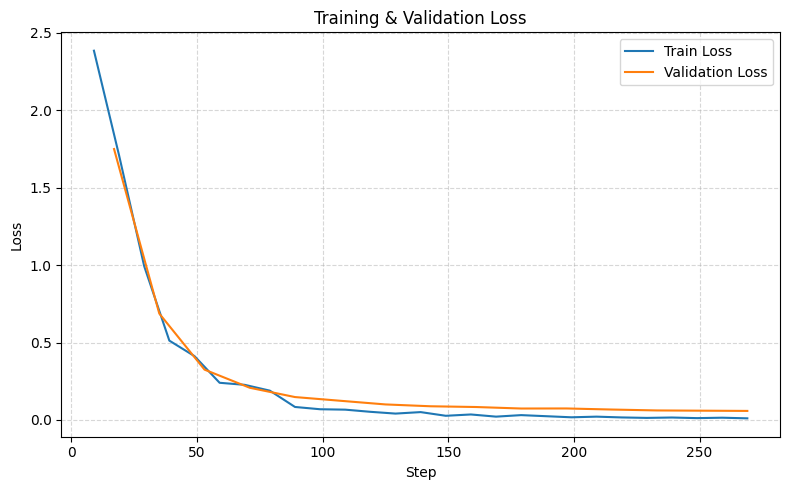

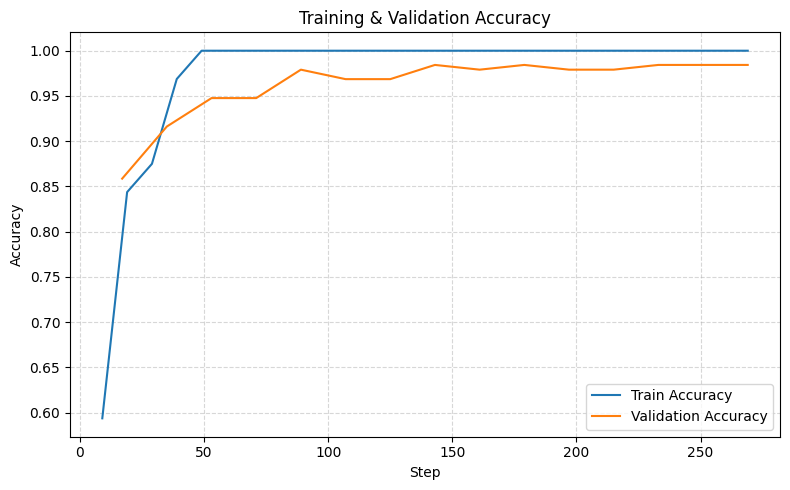

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Find the latest version directory created by the loggers
run_dir = LOG_DIR / RUN_NAME
version_dirs = sorted([p for p in run_dir.glob("version_*") if p.is_dir()],
                      key=lambda p: int(p.name.split("_")[-1]))
if not version_dirs:
    raise FileNotFoundError(f"No version_* folders found under {run_dir}")
latest = version_dirs[-1]
metrics_csv = latest / "metrics.csv"
print("Reading metrics from:", metrics_csv)

df = pd.read_csv(metrics_csv)

# Helper: pick the x-axis. Prefer 'step' if present, else 'epoch' (falls back to index).
x = df["step"] if "step" in df.columns else (df["epoch"] if "epoch" in df.columns else df.index)

# Filter rows that actually contain each metric
df_train_loss = df[df["train_loss"].notna()] if "train_loss" in df.columns else pd.DataFrame()
df_val_loss   = df[df["val_loss"].notna()]   if "val_loss"   in df.columns else pd.DataFrame()
df_train_acc  = df[df["train_acc"].notna()]  if "train_acc"  in df.columns else pd.DataFrame()
df_val_acc    = df[df["val_acc"].notna()]    if "val_acc"    in df.columns else pd.DataFrame()

# ---- Plot 1: Train vs Validation Loss ----
plt.figure(figsize=(8, 5))
if not df_train_loss.empty:
    plt.plot(df_train_loss["step"] if "step" in df_train_loss else df_train_loss.index,
             df_train_loss["train_loss"], label="Train Loss")
if not df_val_loss.empty:
    plt.plot(df_val_loss["step"] if "step" in df_val_loss else df_val_loss.index,
             df_val_loss["val_loss"], label="Validation Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# ---- Plot 2: Train vs Validation Accuracy ----
plt.figure(figsize=(8, 5))
if not df_train_acc.empty:
    plt.plot(df_train_acc["step"] if "step" in df_train_acc else df_train_acc.index,
             df_train_acc["train_acc"], label="Train Accuracy")
if not df_val_acc.empty:
    plt.plot(df_val_acc["step"] if "step" in df_val_acc else df_val_acc.index,
             df_val_acc["val_acc"], label="Validation Accuracy")
plt.xlabel("Step")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


## 15) Test the final (non-checkpoint) model on the test dataset

In [16]:
trainer.test(model, datamodule=data_module)

Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9895287752151489     │
│          test_f1          │    0.9662790298461914     │
│         test_loss         │    0.04322947934269905    │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.04322947934269905,
  'test_acc': 0.9895287752151489,
  'test_f1': 0.9662790298461914}]

## 16) Load the best checkpoint and evaluate it on the test set

In [17]:
# Load the best model (optional)
best_model_path = checkpoint_callback.best_model_path
print(f"Best model saved at: {best_model_path}")

# Alternative: load a specific checkpoint manually
# best_model_path = "KiWi_logs/individual_identification/version_3/checkpoints/best-individual-identification-KiWi.ckpt"

best_model = BirdsongClassifier.load_from_checkpoint(best_model_path)
best_model.eval()
# Evaluate the best model on the test set
results = trainer.test(best_model, datamodule=data_module)

# Print all metrics in a nice format
print("\nTest Metrics:")
for metric, value in results[0].items():
    print(f"{metric}: {value:.4f} ({value*100:.1f}%)" if "acc" in metric or "f1" in metric else f"{metric}: {value:.4f}")

test_acc = results[0]['test_acc']   # lo multiplicas por 100 para tenerlo en porcentaje


Best model saved at: /teamspace/studios/this_studio/logs/littleowl/acrossyear/littleowl_acrossyear_birdnet_lstm_shuffled/version_6/checkpoints/best-littleowl-acrossyear-birdnet_lstm_shuffled-epoch=04-val_f1=0.9388.ckpt


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9842932224273682     │
│          test_f1          │    0.9641311168670654     │
│         test_loss         │    0.1371506154537201     │
└───────────────────────────┴───────────────────────────┘


Test Metrics:
test_loss: 0.1372
test_acc: 0.9843 (98.4%)
test_f1: 0.9641 (96.4%)


## 17) Test set classification report for the best model

In [ ]:
from sklearn.metrics import classification_report
import numpy as np
import torch

# Load best checkpoint (if not already loaded)
best_model = BirdsongClassifier.load_from_checkpoint(best_model_path)
best_model.eval()

# Put model on the right device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
best_model.to(device)

all_preds, all_labels = [], []

# Iterate over the test loader
with torch.no_grad():
    for x, lengths, y in data_module.test_dataloader():
        x = x.to(device)
        lengths = lengths.to(device)
        y = y.to(device)

        logits = best_model(x, lengths)
        preds = torch.argmax(logits, dim=1)

        all_preds.append(preds.cpu().numpy())
        all_labels.append(y.cpu().numpy())

y_true = np.concatenate(all_labels)
y_pred = np.concatenate(all_preds)

# Map class indices -> original string labels from your LabelEncoder
labels = list(range(len(le.classes_)))
target_names = [str(c) for c in le.classes_]

report_text = classification_report(
    y_true,
    y_pred,
    labels=labels,
    target_names=target_names,
    digits=4,
    zero_division=0,   # avoids warnings if a class has no predicted samples
)

print(report_text)

# save the report alongside TensorBoard logs
with open(CLASS_REPORT_TXT_FILE, "w") as f:
     f.write(report_text)
print(f"\nSaved classification report (txt) to: {CLASS_REPORT_TXT_FILE}")


# Dictionary report for CSV export
report_dict = classification_report(
    y_true,
    y_pred,
    labels=labels,
    target_names=target_names,
    digits=4,
    output_dict=True
)
report_df = pd.DataFrame(report_dict).transpose()

# Optional: keep only per-individual rows
per_class_report_df = report_df.loc[list(le.classes_)].reset_index()
per_class_report_df = per_class_report_df.rename(columns={"index": "individual"})

per_class_report_df.to_csv(CLASS_REPORT_CSV_FILE, index=False)

print(f"Saved classification report (csv) to: {CLASS_REPORT_CSV_FILE}")
display(per_class_report_df.head())

              precision    recall  f1-score   support

         108     1.0000    1.0000    1.0000        14
         193     1.0000    1.0000    1.0000        11
         229     1.0000    0.9231    0.9600        13
           7     1.0000    0.9231    0.9600        13
          94     1.0000    1.0000    1.0000        10
         BRE     1.0000    1.0000    1.0000        11
         CER     1.0000    1.0000    1.0000        10
         DUB     1.0000    1.0000    1.0000        11
         KME     1.0000    1.0000    1.0000        11
         LIS     1.0000    1.0000    1.0000        14
         MNE     1.0000    1.0000    1.0000        14
         PAL     0.8462    1.0000    0.9167        11
         RAC     0.9333    1.0000    0.9655        14
       RADBF     1.0000    0.9231    0.9600        13
        RADK     1.0000    1.0000    1.0000         9
         VEV     1.0000    1.0000    1.0000        12

    accuracy                         0.9843       191
   macro avg     0.9862   

,individual,precision,recall,f1-score,support
0,108,1.0,1.000000,1.00,14.0
1,193,1.0,1.000000,1.00,11.0
2,229,1.0,0.923077,0.96,13.0
3,7,1.0,0.923077,0.96,13.0
4,94,1.0,1.000000,1.00,10.0


## 18) Model evaluation function with metrics and ROC AUC

In [19]:
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, recall_score, balanced_accuracy_score, accuracy_score, roc_auc_score
)
from sklearn.preprocessing import label_binarize
import numpy as np
import torch
import matplotlib.pyplot as plt

def evaluate_split(model, loader, le, split_name: str):
    """Evaluate a model on a dataloader and compute multiple metrics."""
    model.eval()
    device = next(model.parameters()).device

    all_preds, all_labels, all_logits = [], [], []

    with torch.no_grad():
        for x, lengths, y in loader:
            x = x.to(device)
            lengths = lengths.to(device)
            y = y.to(device)

            logits = model(x, lengths)
            preds = torch.argmax(logits, dim=1)

            all_logits.append(logits.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_labels.append(y.cpu().numpy())

    # Arrays
    y_true = np.concatenate(all_labels)
    y_pred = np.concatenate(all_preds)
    logits_np = np.concatenate(all_logits, axis=0)

    # Confusion matrix (plot)
    labels = list(range(len(le.classes_)))
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_).plot(
        ax=ax, xticks_rotation=45, cmap="Blues", colorbar=True
    )
    ax.set_title(f"Confusion Matrix — {split_name}")
    plt.tight_layout()
    plt.show()

    # Metrics
    acc = accuracy_score(y_true, y_pred)
    acc_bal = balanced_accuracy_score(y_true, y_pred)
    recall_macro    = recall_score(y_true, y_pred, labels=labels, average="macro",    zero_division=0)
    recall_weighted = recall_score(y_true, y_pred, labels=labels, average="weighted", zero_division=0)
    f1_macro        = f1_score(y_true, y_pred,     labels=labels, average="macro",    zero_division=0)
    f1_weighted     = f1_score(y_true, y_pred,     labels=labels, average="weighted", zero_division=0)

    # ROC AUC (macro)
    num_classes = len(np.unique(y_true))
    y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))
    probs = torch.softmax(torch.tensor(logits_np), dim=1).numpy()
    roc_auc_macro = roc_auc_score(y_true_bin, probs, average="macro", multi_class="ovr")

    # Print and return
    print(f"{split_name} — Accuracy:          {acc:.4f} ({acc*100:.1f}%)")
    print(f"{split_name} — Balanced accuracy: {acc_bal:.4f} ({acc_bal*100:.1f}%)")
    print(f"{split_name} — Recall (macro):    {recall_macro:.4f}")
    print(f"{split_name} — Recall (weighted): {recall_weighted:.4f}")
    print(f"{split_name} — F1 (macro):        {f1_macro:.4f} ({f1_macro*100:.1f}%)")
    print(f"{split_name} — F1 (weighted):     {f1_weighted:.4f}")
    print(f"{split_name} — ROC AUC (macro):   {roc_auc_macro:.4f}\n")

    return {
        "accuracy": acc,
        "balanced_accuracy": acc_bal,
        "recall_macro": recall_macro,
        "recall_weighted": recall_weighted,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "roc_auc_macro": roc_auc_macro,
    }



## 19) Evaluate best model on Validation and Test sets, 
then plot Test metrics as a bubble chart

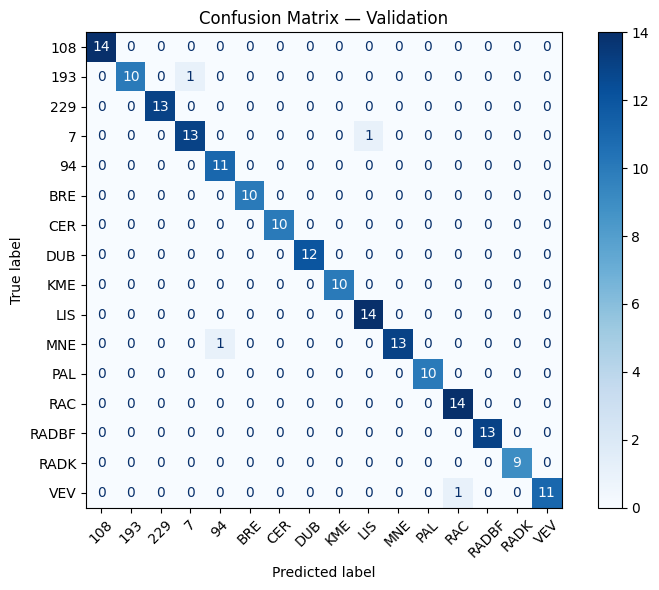

Validation — Accuracy:          0.9791 (97.9%)
Validation — Balanced accuracy: 0.9802 (98.0%)
Validation — Recall (macro):    0.9802
Validation — Recall (weighted): 0.9791
Validation — F1 (macro):        0.9805 (98.0%)
Validation — F1 (weighted):     0.9790
Validation — ROC AUC (macro):   0.9999



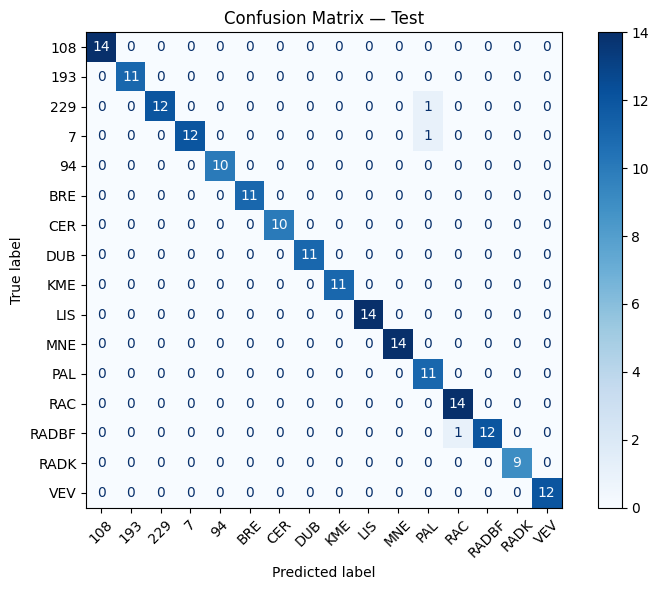

Test — Accuracy:          0.9843 (98.4%)
Test — Balanced accuracy: 0.9856 (98.6%)
Test — Recall (macro):    0.9856
Test — Recall (weighted): 0.9843
Test — F1 (macro):        0.9851 (98.5%)
Test — F1 (weighted):     0.9845
Test — ROC AUC (macro):   0.9999



In [20]:
# Ensure the model is on the right device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
best_model.to(device)

# Evaluate and collect metrics
val_metrics  = evaluate_split(best_model, data_module.val_dataloader(),  le, "Validation")
test_metrics = evaluate_split(best_model, data_module.test_dataloader(), le, "Test")


## 20) Saving metrics

In [21]:
summary_row = {
    "run_name": RUN_NAME,
    "seed": SEED,
    "dataset_name": DATASET_NAME,
    "split_type": SPLIT_TYPE,
    "sequence_mode": SEQUENCE,
    "embedding_dim": EMBEDDING_DIM,
    "hidden_dim": HIDDEN_DIM,
    "learning_rate": LEARNING_RATE,

    "val_accuracy": val_metrics["accuracy"],
    "val_balanced_accuracy": val_metrics["balanced_accuracy"],
    "val_recall_macro": val_metrics["recall_macro"],
    "val_recall_weighted": val_metrics["recall_weighted"],
    "val_f1_macro": val_metrics["f1_macro"],
    "val_f1_weighted": val_metrics["f1_weighted"],
    "val_roc_auc_macro": val_metrics["roc_auc_macro"],

    "test_accuracy": test_metrics["accuracy"],
    "test_balanced_accuracy": test_metrics["balanced_accuracy"],
    "test_recall_macro": test_metrics["recall_macro"],
    "test_recall_weighted": test_metrics["recall_weighted"],
    "test_f1_macro": test_metrics["f1_macro"],
    "test_f1_weighted": test_metrics["f1_weighted"],
    "test_roc_auc_macro": test_metrics["roc_auc_macro"],
}

new_row_df = pd.DataFrame([summary_row])

key_cols = ["run_name", "seed"]

if METRICS_FILE.exists():
    metrics_df = pd.read_csv(METRICS_FILE)

    missing_cols = [c for c in key_cols if c not in metrics_df.columns]
    if missing_cols:
        raise ValueError(
            f"Missing key columns in existing metrics file: {missing_cols}"
        )

    mask = pd.Series(True, index=metrics_df.index)
    for col in key_cols:
        mask &= metrics_df[col] == summary_row[col]

    if mask.any():
        metrics_df = metrics_df.loc[~mask].copy()
        action = "updated"
    else:
        action = "appended"

    metrics_df = pd.concat([metrics_df, new_row_df], ignore_index=True)

else:
    metrics_df = new_row_df.copy()
    action = "created"

metrics_df = metrics_df.sort_values(by=key_cols).reset_index(drop=True)
metrics_df.to_csv(METRICS_FILE, index=False)

print(f"Metrics file {action}: {METRICS_FILE}")
display(metrics_df)

Metrics file updated: /teamspace/studios/this_studio/Results/littleowl/acrossyear/Metrics/littleowl_acrossyear_birdnet_lstm_shuffled_final_metrics.csv


,run_name,seed,dataset_name,split_type,sequence_mode,embedding_dim,hidden_dim,learning_rate,val_accuracy,val_balanced_accuracy,...,val_f1_macro,val_f1_weighted,val_roc_auc_macro,test_accuracy,test_balanced_accuracy,test_recall_macro,test_recall_weighted,test_f1_macro,test_f1_weighted,test_roc_auc_macro
0,littleowl_acrossyear_birdnet_lstm_shuffled,18,littleowl,acrossyear,shuffled,1024,256,0.001,0.984293,0.982860,...,0.984350,0.984371,0.99956,0.984293,0.985176,0.985176,0.984293,0.985961,0.984409,0.999884
1,littleowl_acrossyear_birdnet_lstm_shuffled,23,littleowl,acrossyear,shuffled,1024,256,0.001,0.994764,0.995192,...,0.995345,0.994750,1.00000,0.989529,0.989854,0.989854,0.989529,0.989578,0.989522,0.999316
2,littleowl_acrossyear_birdnet_lstm_shuffled,46,littleowl,acrossyear,shuffled,1024,256,0.001,0.979058,0.980181,...,0.980500,0.979017,0.99989,0.984293,0.985577,0.985577,0.984293,0.985136,0.984506,0.999946


## 21) Bubble plot from TEST metrics

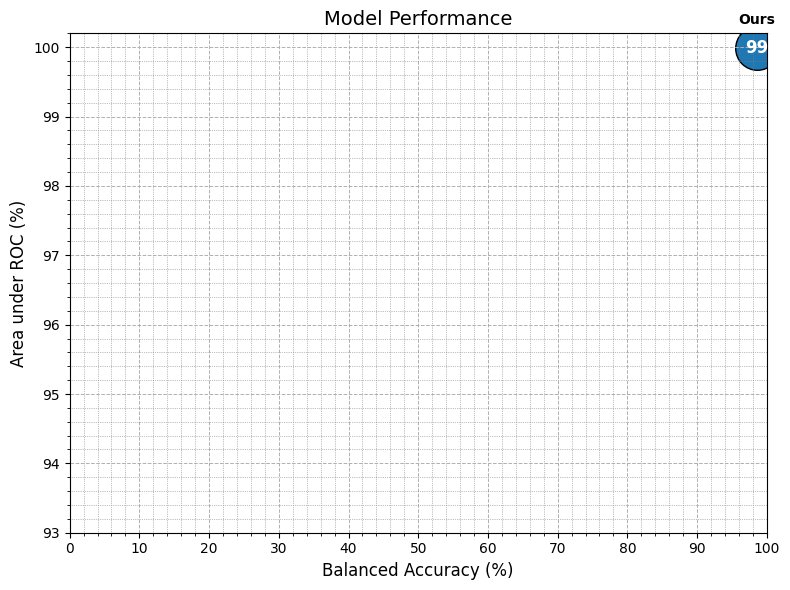

In [22]:

# --- Bubble plot from TEST metrics ---
import matplotlib.pyplot as plt
import numpy as np

# Metrics for the figure
balanced_accuracy = test_metrics["balanced_accuracy"] * 100   # Balanced Accuracy (%)
roc_auc = test_metrics["roc_auc_macro"] * 100            # Area under ROC (%)
f1_macro = test_metrics["f1_macro"]                       # 0..1
model_name = "Ours"

# Figure
fig, ax = plt.subplots(figsize=(8, 6))

# Bubble size proportional to F1 (tune the factor if needed)
bubble_size = 1000 * f1_macro

# Scatter
ax.scatter(balanced_accuracy, roc_auc, s=bubble_size, edgecolors='black', alpha=1)

# Text inside bubble: F1 in percent, rounded
ax.text(balanced_accuracy, roc_auc, f"{int(round(f1_macro*100))}",
        fontsize=12, ha='center', va='center', color='white', fontweight='bold')

# Model name above bubble
ax.text(balanced_accuracy, roc_auc + 0.3, model_name,
        fontsize=10, ha='center', va='bottom', color='black', fontweight='bold')

# Axes customization (adjust if your ranges differ)
ax.set_xlim(0, 100)
ax.set_ylim(93, 100.2)

ax.set_xticks(np.arange(0, 101, 10))
ax.set_yticks(np.arange(93, 100.2, 1))
ax.set_xticks(np.arange(0, 101, 2), minor=True)
ax.set_yticks(np.arange(93, 100.2, 0.2), minor=True)

ax.grid(True, which='minor', linestyle=':', linewidth=0.5, color='gray')
ax.grid(True, which='major', linestyle='--', linewidth=0.7)

ax.set_xlabel("Balanced Accuracy (%)", fontsize=12)
ax.set_ylabel("Area under ROC (%)", fontsize=12)
ax.set_title("Model Performance", fontsize=14)

plt.tight_layout()
plt.savefig("LSTM_AudioID_performance.png", dpi=300)
plt.show()
